# 03 — Price Forecasting

Build, evaluate, and compare **statistical and deep-learning time-series models** to forecast avocado `AveragePrice` across all city-level regions, then combine them into an **ensemble** that outperforms any individual model.

## Approach

| Layer | Models | Why |
|---|---|---|
| **Naïve baseline** | Seasonal Naïve | Repeat last year's price — any model must beat this |
| **Statistical** | AutoARIMA, AutoETS, AutoTheta | Capture trend + seasonality; AutoTheta won the M3 competition |
| **Deep learning** | NHITS | Global model trained across all regions simultaneously |
| **Ensemble** | Ensemble_weighted ⭐ | Inverse-MAE weighted combination of all 5 base models — primary output |

### Why an ensemble?

- **Diversity wins** — statistical models (seasonality-focused) and NHITS (non-linear patterns) make orthogonal errors; averaging them cancels noise.
- **Robustness** — no single model dominates all 86 series; the weighted blend adapts to which models are collectively strongest.
- **`Ensemble_weighted` is the primary model** used by all downstream notebooks (04–06) and the API.

### Key design choices

- **Horizon** `H = 12 weeks` (≈ 3 months) — practical for business planning.
- **Lookback** `input_size = 2 × H = 24 weeks` — gives the model 6 months of context.
- **Evaluation** — cross-validation with `n_windows=1` (temporal holdout of last 12 weeks).
- **Ensemble weights** — derived from CV MAE; stored in `data/outputs/ensemble_weights.csv`.

### Exogenous features (NHITS only)

| Type | Features | Rationale |
|---|---|---|
| **Future-known** | `month_sin`, `month_cos`, `week_sin`, `week_cos`, `is_holiday_week` | Calendar features are known at prediction time |
| **Static** | `is_organic`, `region_price_level`, `region_volume_level` | Constant per series — encode structural differences |

## 1. Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import time
import warnings
import logging

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# --- Statistical forecasting (Nixtla) ---
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, AutoARIMA, AutoETS, AutoTheta

# --- Deep-learning forecasting (Nixtla) ---
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

HAS_TIMESNET = False
try:
    from neuralforecast.models import TimesNet
    HAS_TIMESNET = True
except ImportError:
    print("⚠ TimesNet not available in this neuralforecast version — NHITS only")

# Reduce PyTorch Lightning verbosity during training
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
logging.getLogger("lightning.pytorch").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*'W' is deprecated.*")

# --- Plot style ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)

# --- Paths ---
DATA_PROCESSED = Path("../data/processed")
DATA_OUTPUTS   = Path("../data/outputs")
DATA_OUTPUTS.mkdir(parents=True, exist_ok=True)

# --- Forecasting hyperparameters ---
H       = 12    # forecast horizon (weeks ≈ 3 months)
SEASON  = 52    # annual seasonality for weekly data
SEED    = 42

print(f"Horizon: {H} weeks | Lookback: {2*H} weeks | Season: {SEASON} weeks")
print(f"TimesNet available: {HAS_TIMESNET}")
print("✔ Imports loaded")

## 2. Data Preparation

Load the processed feature matrix from notebook 02 and convert it to the
[Nixtla long format](https://nixtlaverse.nixtla.io/) required by both StatsForecast and NeuralForecast:

| Column | Description |
|---|---|
| `unique_id` | Identifier for each individual time series |
| `ds` | Datestamp |
| `y` | Target value (AveragePrice) |
| *exog columns* | Additional features for the neural models |

In [2]:
csv_path = DATA_PROCESSED / "avocado_features.csv"
assert csv_path.exists(), (
    f"File not found: {csv_path}\n"
    "→ Run notebook 02_feature_engineering.ipynb first to generate the processed data."
)

df = pd.read_csv(csv_path, parse_dates=["Date"])

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Regions: {df['region'].nunique()}, Types: {df['is_organic'].nunique()}")
df.head(3)

Loaded: 14,190 rows × 42 columns
Date range: 2015-02-01 → 2018-03-25
Regions: 43, Types: 2


,Date,AveragePrice,Total Volume,region,is_organic,year,month,week,day_of_week,quarter,...,volume_lag_4w,price_rmean_4w,price_rmean_8w,price_rmean_12w,price_rstd_4w,price_pct_change_1w,price_momentum_4w,volume_rmean_4w,region_price_level,region_volume_level
0,2015-02-01,0.99,70873.60,Albany,0,2015,2,5,6,1,...,40873.28,1.1725,1.172500,1.172500,0.080571,-0.066038,-0.1825,42931.7850,1.570605,10.742067
1,2015-02-08,0.99,51253.97,Albany,0,2015,2,6,6,1,...,41195.08,1.1150,1.136000,1.136000,0.111505,0.000000,-0.1250,50431.8650,1.570605,10.742067
2,2015-02-15,1.06,41567.62,Albany,0,2015,2,7,6,1,...,44511.28,1.0525,1.111667,1.111667,0.085000,0.070707,0.0075,52946.5875,1.570605,10.742067


### 2.1 Convert to Nixtla Format

Each (region, type) combination becomes its own time series with a `unique_id`.

We carefully separate features into:
- **Future exogenous** — calendar-derived features whose values are known at prediction time.
- **Static exogenous** — features constant per series (type flag, regional encodings).

In [3]:
# Create unique_id = "Region_type"
df["unique_id"] = (
    df["region"] + "_" + df["is_organic"].map({0: "conventional", 1: "organic"})
)

# Rename to nixtla standard
nf_df = df.rename(columns={"Date": "ds", "AveragePrice": "y"}).copy()

# ---- Exogenous feature groups ----
# Future-known: deterministic calendar features computable for any future date
FUTR_EXOG = [
    "month_sin", "month_cos",    # cyclical month encoding
    "week_sin",  "week_cos",     # cyclical week encoding
    "is_holiday_week",           # calendar-based → known in advance
]

# Static: constant per series — encode structural differences
STAT_EXOG = [
    "is_organic",                # binary type flag
    "region_price_level",        # target-encoded regional price level
    "region_volume_level",       # target-encoded regional volume level
]

# Select only the columns needed for time-series forecasting
nf_cols = ["unique_id", "ds", "y"] + FUTR_EXOG + STAT_EXOG
nf_df = nf_df[nf_cols].sort_values(["unique_id", "ds"]).reset_index(drop=True)

# Minimal version for StatsForecast (univariate — no exogenous support for baselines)
sf_df = nf_df[["unique_id", "ds", "y"]].copy()

N_SERIES = nf_df["unique_id"].nunique()
print(f"Time series: {N_SERIES}")
print(f"Total rows:  {len(nf_df):,}")
print(f"Future exog: {FUTR_EXOG}")
print(f"Static exog: {STAT_EXOG}")
nf_df.head()

Time series: 86
Total rows:  14,190
Future exog: ['month_sin', 'month_cos', 'week_sin', 'week_cos', 'is_holiday_week']
Static exog: ['is_organic', 'region_price_level', 'region_volume_level']


,unique_id,ds,y,month_sin,month_cos,week_sin,week_cos,is_holiday_week,is_organic,region_price_level,region_volume_level
0,Albany_conventional,2015-02-01,0.99,0.866025,5.000000e-01,0.568065,0.822984,1,0,1.570605,10.742067
1,Albany_conventional,2015-02-08,0.99,0.866025,5.000000e-01,0.663123,0.748511,0,0,1.570605,10.742067
2,Albany_conventional,2015-02-15,1.06,0.866025,5.000000e-01,0.748511,0.663123,0,0,1.570605,10.742067
3,Albany_conventional,2015-02-22,1.07,0.866025,5.000000e-01,0.822984,0.568065,0,0,1.570605,10.742067
4,Albany_conventional,2015-03-01,0.99,1.000000,6.123234e-17,0.885456,0.464723,0,0,1.570605,10.742067


### 2.2 Series Overview

Verify all series have consistent length and no temporal gaps.

Series length — min: 165, max: 165, mean: 165


Series with temporal gaps: 0 / 86


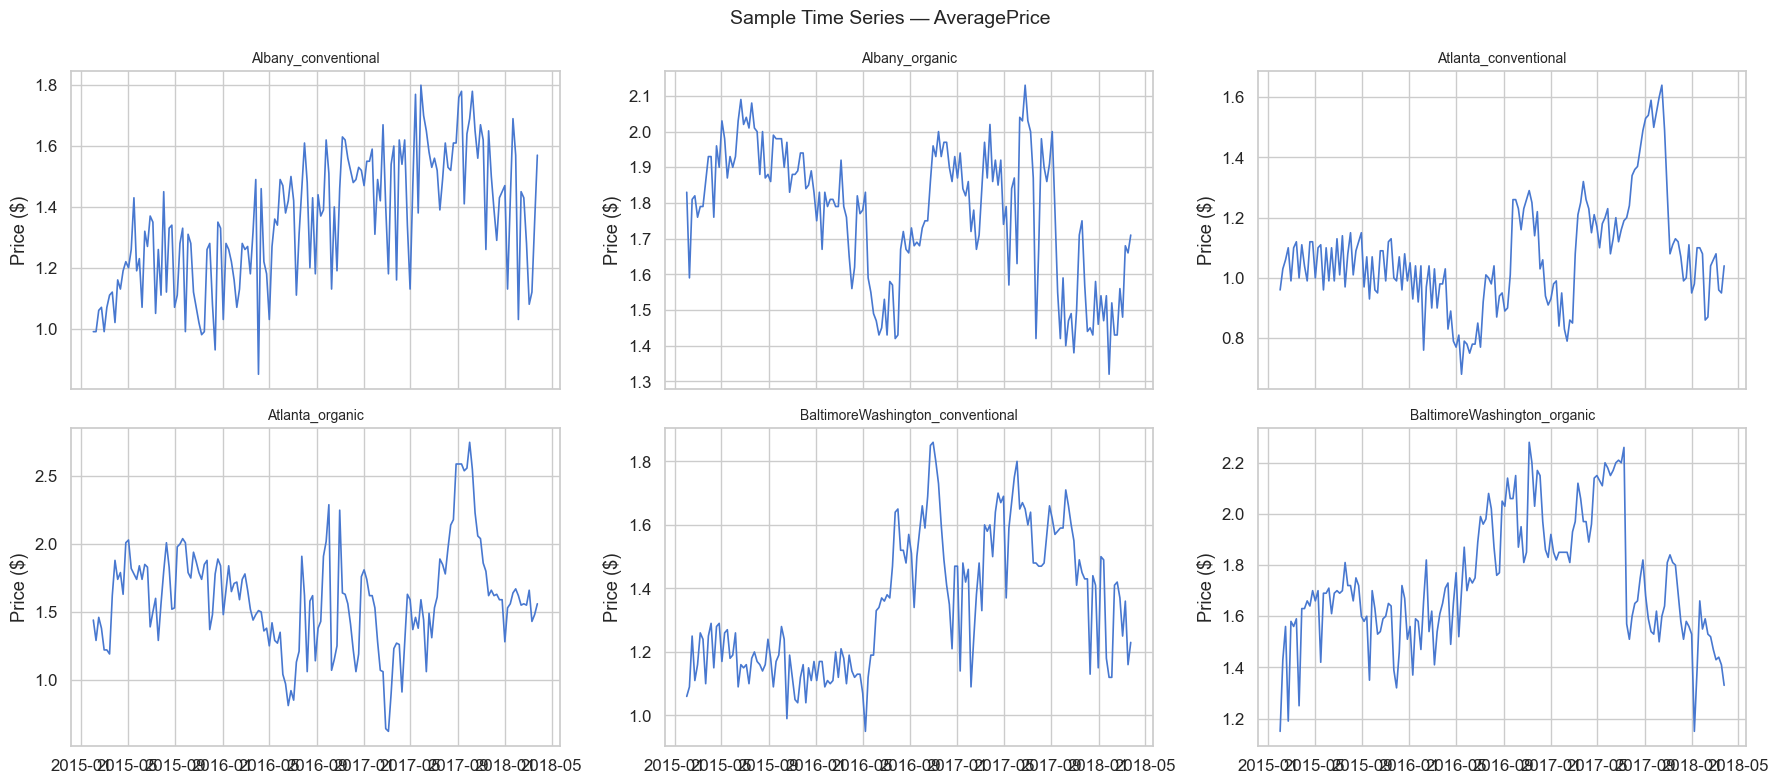

In [4]:
# Length distribution
series_len = nf_df.groupby("unique_id").size()
print(f"Series length — min: {series_len.min()}, max: {series_len.max()}, "
      f"mean: {series_len.mean():.0f}")

# Check for temporal gaps within each series
def check_gaps(group):
    diffs = group["ds"].diff().dt.days.dropna()
    return (diffs > 8).sum()  # >8 days = gap (weekly data ≈ 7 days)

gaps = nf_df.groupby("unique_id").apply(check_gaps)
print(f"Series with temporal gaps: {(gaps > 0).sum()} / {N_SERIES}")

# Plot sample series
sample_ids = sorted(nf_df["unique_id"].unique())[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
for ax, uid in zip(axes.flat, sample_ids):
    s = nf_df[nf_df["unique_id"] == uid]
    ax.plot(s["ds"], s["y"], linewidth=1.2)
    ax.set_title(uid, fontsize=10)
    ax.set_ylabel("Price ($)")
plt.suptitle("Sample Time Series — AveragePrice", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Train / Test Split

We use a **temporal holdout**: the last `H = 12` weeks of every series become the test set.

This mirrors what `cross_validation(n_windows=1)` does internally,
but we visualise the split here for transparency.

> In production you'd use expanding-window cross-validation (`n_windows > 1`)  
> for more robust estimates.  We keep `n_windows=1` to maintain reasonable  
> training time for a portfolio project.

Cutoff date  : 2017-12-31
Train period : 2015-02-01 → 2017-12-31  (13,158 rows)
Test period  : 2017-12-31 → 2018-03-25  (1,032 rows)
Train/Test   : 93% / 7%


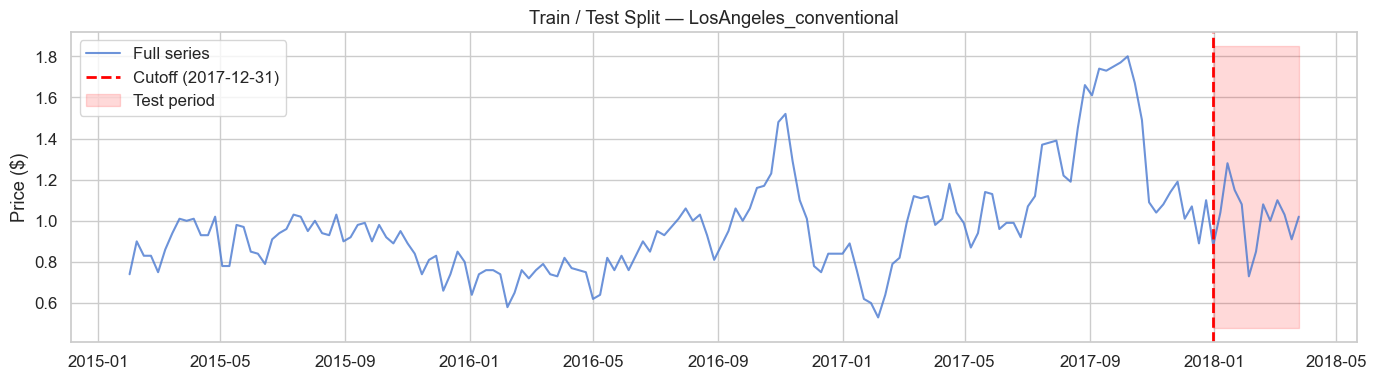

In [5]:
# The cutoff is the last date available minus H weeks
cutoff_date = nf_df.groupby("unique_id")["ds"].max().min() - pd.Timedelta(weeks=H)

train_rows = nf_df[nf_df["ds"] <= cutoff_date].shape[0]
test_rows  = nf_df[nf_df["ds"] > cutoff_date].shape[0]

print(f"Cutoff date  : {cutoff_date.date()}")
print(f"Train period : {nf_df['ds'].min().date()} → {cutoff_date.date()}  ({train_rows:,} rows)")
print(f"Test period  : {cutoff_date.date()} → {nf_df['ds'].max().date()}  ({test_rows:,} rows)")
print(f"Train/Test   : {train_rows/(train_rows+test_rows):.0%} / {test_rows/(train_rows+test_rows):.0%}")

# Visualise split for one series
uid_example = "LosAngeles_conventional"
s = nf_df[nf_df["unique_id"] == uid_example]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(s["ds"], s["y"], label="Full series", alpha=0.8)
ax.axvline(cutoff_date, color="red", ls="--", lw=2, label=f"Cutoff ({cutoff_date.date()})")
ax.fill_betweenx([s["y"].min()-0.05, s["y"].max()+0.05],
                 cutoff_date, s["ds"].max(),
                 alpha=0.15, color="red", label="Test period")
ax.set_title(f"Train / Test Split — {uid_example}")
ax.set_ylabel("Price ($)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Statistical Base Models (StatsForecast)

Four classical models, each fitted **independently per series** via `cross_validation(n_windows=1)`:

| Model | Description |
|---|---|
| **Seasonal Naïve** | Repeat the value from the same week last year. Simplest possible seasonal baseline. |
| **AutoARIMA** | Automatic ARIMA order selection (Hyndman-Khandakar algorithm). Captures trend + seasonality. |
| **AutoETS** | Automatic Exponential Smoothing (Error-Trend-Season). Robust for seasonal data. |
| **AutoTheta** | Automatic Theta decomposition — M3 forecasting competition winner. Decomposes series into trend + cyclical components. |

These four models, combined with NHITS from section 5, form the five-model pool used by `Ensemble_weighted`.

In [ ]:
sf_models = [
    SeasonalNaive(season_length=SEASON),
    AutoARIMA(season_length=SEASON),
    AutoETS(season_length=SEASON),
    AutoTheta(season_length=SEASON),   # M3 competition winner; Theta decomposition
]

sf = StatsForecast(models=sf_models, freq="W", n_jobs=-1)

print(f"Fitting {len(sf_models)} statistical models on {N_SERIES} series...")
t0 = time.time()
sf_cv = sf.cross_validation(df=sf_df, h=H, n_windows=1)
sf_time = time.time() - t0

# Reset index — StatsForecast may set unique_id as index
sf_cv = sf_cv.reset_index()

print(f"✔ StatsForecast done in {sf_time:.1f}s")
print(f"CV output shape: {sf_cv.shape}")
sf_cv.head()

## 5. Deep Learning Models (NeuralForecast)

### NHITS — Neural Hierarchical Interpolation for Time Series

NHITS ([Challu et al., 2023](https://arxiv.org/abs/2201.12886)) is purpose-built for **long-horizon forecasting**:
- Uses **multi-rate signal sampling** — different blocks focus on different frequency components.
- **Hierarchical interpolation** reconstructs the forecast at the original resolution.
- Much faster than Transformers while achieving comparable or better accuracy.

### TimesNet — Temporal 2D-Variation Modeling

TimesNet ([Wu et al., 2023](https://arxiv.org/abs/2210.02186)) transforms 1D time series into
**2D tensors** based on detected periodicities, then applies 2D convolutions (inception blocks).
This elegantly captures multi-scale temporal patterns.

> Both models are trained as **global models** — a single set of weights
> serves all ~90 series, sharing statistical strength across regions.

In [7]:
# ---- NHITS configuration ----
nhits = NHITS(
    h=H,
    input_size=2 * H,                # 24-week lookback (2× horizon)
    futr_exog_list=FUTR_EXOG,
    stat_exog_list=STAT_EXOG,
    scaler_type="robust",            # robust to volume/price outliers
    max_steps=500,                   # training iterations
    learning_rate=1e-3,
    early_stop_patience_steps=10,    # stop if val loss stalls for 10 checks
    val_check_steps=50,              # validate every 50 steps
    random_seed=SEED,
    accelerator="auto",             # GPU if available, else CPU
    enable_progress_bar=True,
)

nf_models = [nhits]
print(f"NHITS configured — input_size={2*H}, h={H}, max_steps=500")

# ---- TimesNet configuration (if available) ----
if HAS_TIMESNET:
    try:
        timesnet = TimesNet(
            h=H,
            input_size=2 * H,
            futr_exog_list=FUTR_EXOG,
            stat_exog_list=STAT_EXOG,
            scaler_type="robust",
            max_steps=300,               # fewer steps — heavier per-step cost
            learning_rate=1e-3,
            early_stop_patience_steps=10,
            val_check_steps=50,
            random_seed=SEED,
            accelerator="auto",
            hidden_size=64,
            conv_hidden_size=32,
            top_k=3,                     # number of periodicities to capture
            enable_progress_bar=True,
        )
        nf_models.append(timesnet)
        print(f"TimesNet configured — hidden=64, conv_hidden=32, top_k=3")
    except Exception as e:
        HAS_TIMESNET = False
        print(f"⚠ TimesNet config failed ({e}) — continuing with NHITS only")

print(f"\nModels to train: {[type(m).__name__ for m in nf_models]}")

Seed set to 42
Seed set to 42


NHITS configured — input_size=24, h=12, max_steps=500
⚠ TimesNet config failed (TimesNet does not support static exogenous variables.) — continuing with NHITS only

Models to train: ['NHITS']


In [8]:
nf = NeuralForecast(models=nf_models, freq="W")

print(f"Training {len(nf_models)} neural model(s) across {N_SERIES} series...")
print("This may take a few minutes on CPU.\n")

t0 = time.time()
# NeuralForecast expects static exogenous variables in a separate static_df
static_df = nf_df[["unique_id"] + STAT_EXOG].drop_duplicates("unique_id")

nf_cv = nf.cross_validation(
    df=nf_df.drop(columns=STAT_EXOG),  # keep temporal + future-known exog only
    static_df=static_df,               # pass static exog explicitly
    n_windows=1,
    val_size=H,
)
nf_time = time.time() - t0

nf_cv = nf_cv.reset_index()

print(f"\n✔ NeuralForecast done in {nf_time:.1f}s")
print(f"CV output shape: {nf_cv.shape}")
nf_cv.head()

Training 1 neural model(s) across 86 series...
This may take a few minutes on CPU.



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]


✔ NeuralForecast done in 72.3s
CV output shape: (1032, 6)


,index,unique_id,ds,cutoff,NHITS,y
0,0,Albany_conventional,2018-01-07,2017-12-31,1.355265,1.13
1,1,Albany_conventional,2018-01-14,2017-12-31,1.386725,1.42
2,2,Albany_conventional,2018-01-21,2017-12-31,1.359625,1.69
3,3,Albany_conventional,2018-01-28,2017-12-31,1.341399,1.57
4,4,Albany_conventional,2018-02-04,2017-12-31,1.263565,1.03


## 6. Model Comparison

### 6.1 Aggregate Metrics

We compare all models on four standard forecasting metrics:

| Metric | Measures | Interpretation |
|---|---|---|
| **MAE** | Average absolute error | Directly interpretable in USD |
| **RMSE** | Root mean squared error | Penalises large errors more than MAE |
| **MAPE** | Mean absolute percentage error | Scale-independent; in percent |
| **SMAPE** | Symmetric MAPE | Better behaved near zero than MAPE |

In [ ]:
def compute_metrics(y_true, y_pred):
    """Compute MAE, RMSE, MAPE, SMAPE between arrays."""
    e   = np.array(y_true) - np.array(y_pred)
    ae  = np.abs(e)
    yt  = np.abs(np.array(y_true))
    yp  = np.abs(np.array(y_pred))
    return {
        "MAE":   ae.mean(),
        "RMSE":  np.sqrt((e**2).mean()),
        "MAPE":  (ae / np.clip(yt, 1e-8, None)).mean() * 100,
        "SMAPE": (2 * ae / np.clip(yt + yp, 1e-8, None)).mean() * 100,
    }


# ---- Identify model columns ----
SF_MODELS = ["SeasonalNaive", "AutoARIMA", "AutoETS", "AutoTheta"]
NF_MODELS = [c for c in nf_cv.columns if c in ["NHITS", "TimesNet"]]
ALL_MODELS = SF_MODELS + NF_MODELS

# ---- Merge CV results ----
# StatsForecast and NeuralForecast both output: unique_id, ds, cutoff, y, <model_cols>
all_cv = sf_cv[["unique_id", "ds", "y"] + SF_MODELS].merge(
    nf_cv[["unique_id", "ds"] + NF_MODELS],
    on=["unique_id", "ds"],
    how="inner",
)
print(f"Merged CV results: {all_cv.shape[0]:,} rows × {len(ALL_MODELS)} models")

# ---- Compute aggregate metrics ----
metrics_rows = []
for model in ALL_MODELS:
    m = compute_metrics(all_cv["y"], all_cv[model])
    m["Model"] = model
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows).set_index("Model")[["MAE", "RMSE", "MAPE", "SMAPE"]]
metrics_df = metrics_df.sort_values("MAE")

# Highlight the best model per metric
print("\n" + "="*60)
print("AGGREGATE METRICS (across all series, all test windows)")
print("="*60)
display(metrics_df.style.highlight_min(axis=0, color="#d4edda")
        .format("{:.4f}", subset=["MAE", "RMSE"])
        .format("{:.2f}%", subset=["MAPE", "SMAPE"]))

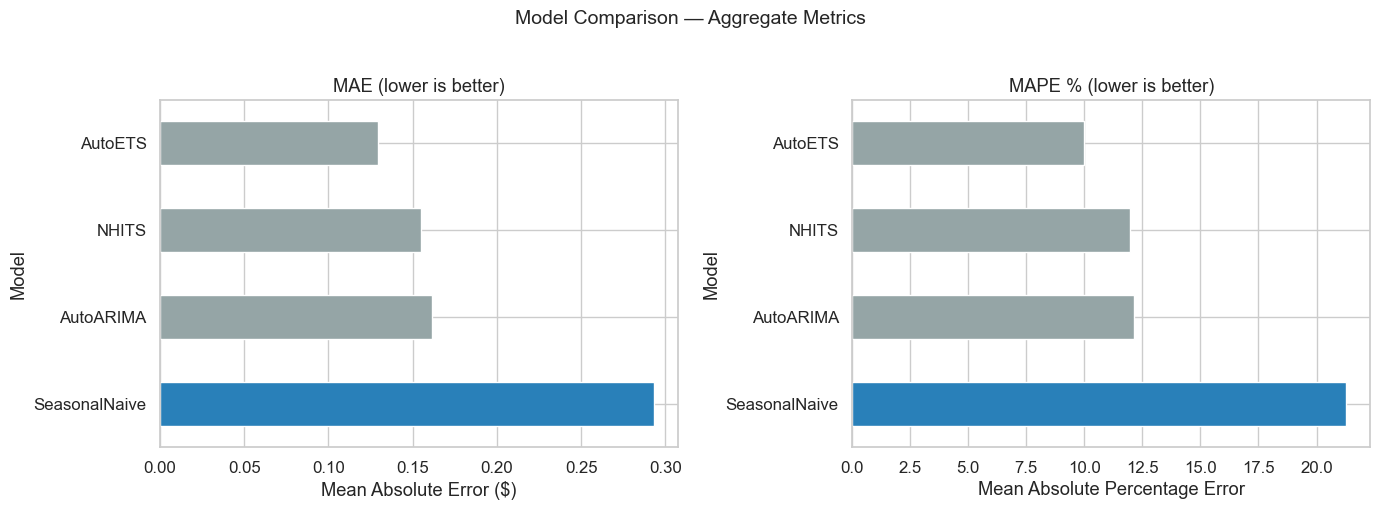

In [10]:
# Bar chart of MAE and MAPE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#95a5a6"] * len(SF_MODELS) + ["#2980b9"] * len(NF_MODELS)

metrics_df["MAE"].plot.barh(ax=axes[0], color=colors, edgecolor="white")
axes[0].set_title("MAE (lower is better)")
axes[0].set_xlabel("Mean Absolute Error ($)")
axes[0].invert_yaxis()

metrics_df["MAPE"].plot.barh(ax=axes[1], color=colors, edgecolor="white")
axes[1].set_title("MAPE % (lower is better)")
axes[1].set_xlabel("Mean Absolute Percentage Error")
axes[1].invert_yaxis()

plt.suptitle("Model Comparison — Aggregate Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Forecast vs Actual — Selected Regions

Visual comparison for a handful of representative regions.  
We show the **training tail** (last 24 weeks) plus the **12-week forecast** overlaid on actual values.

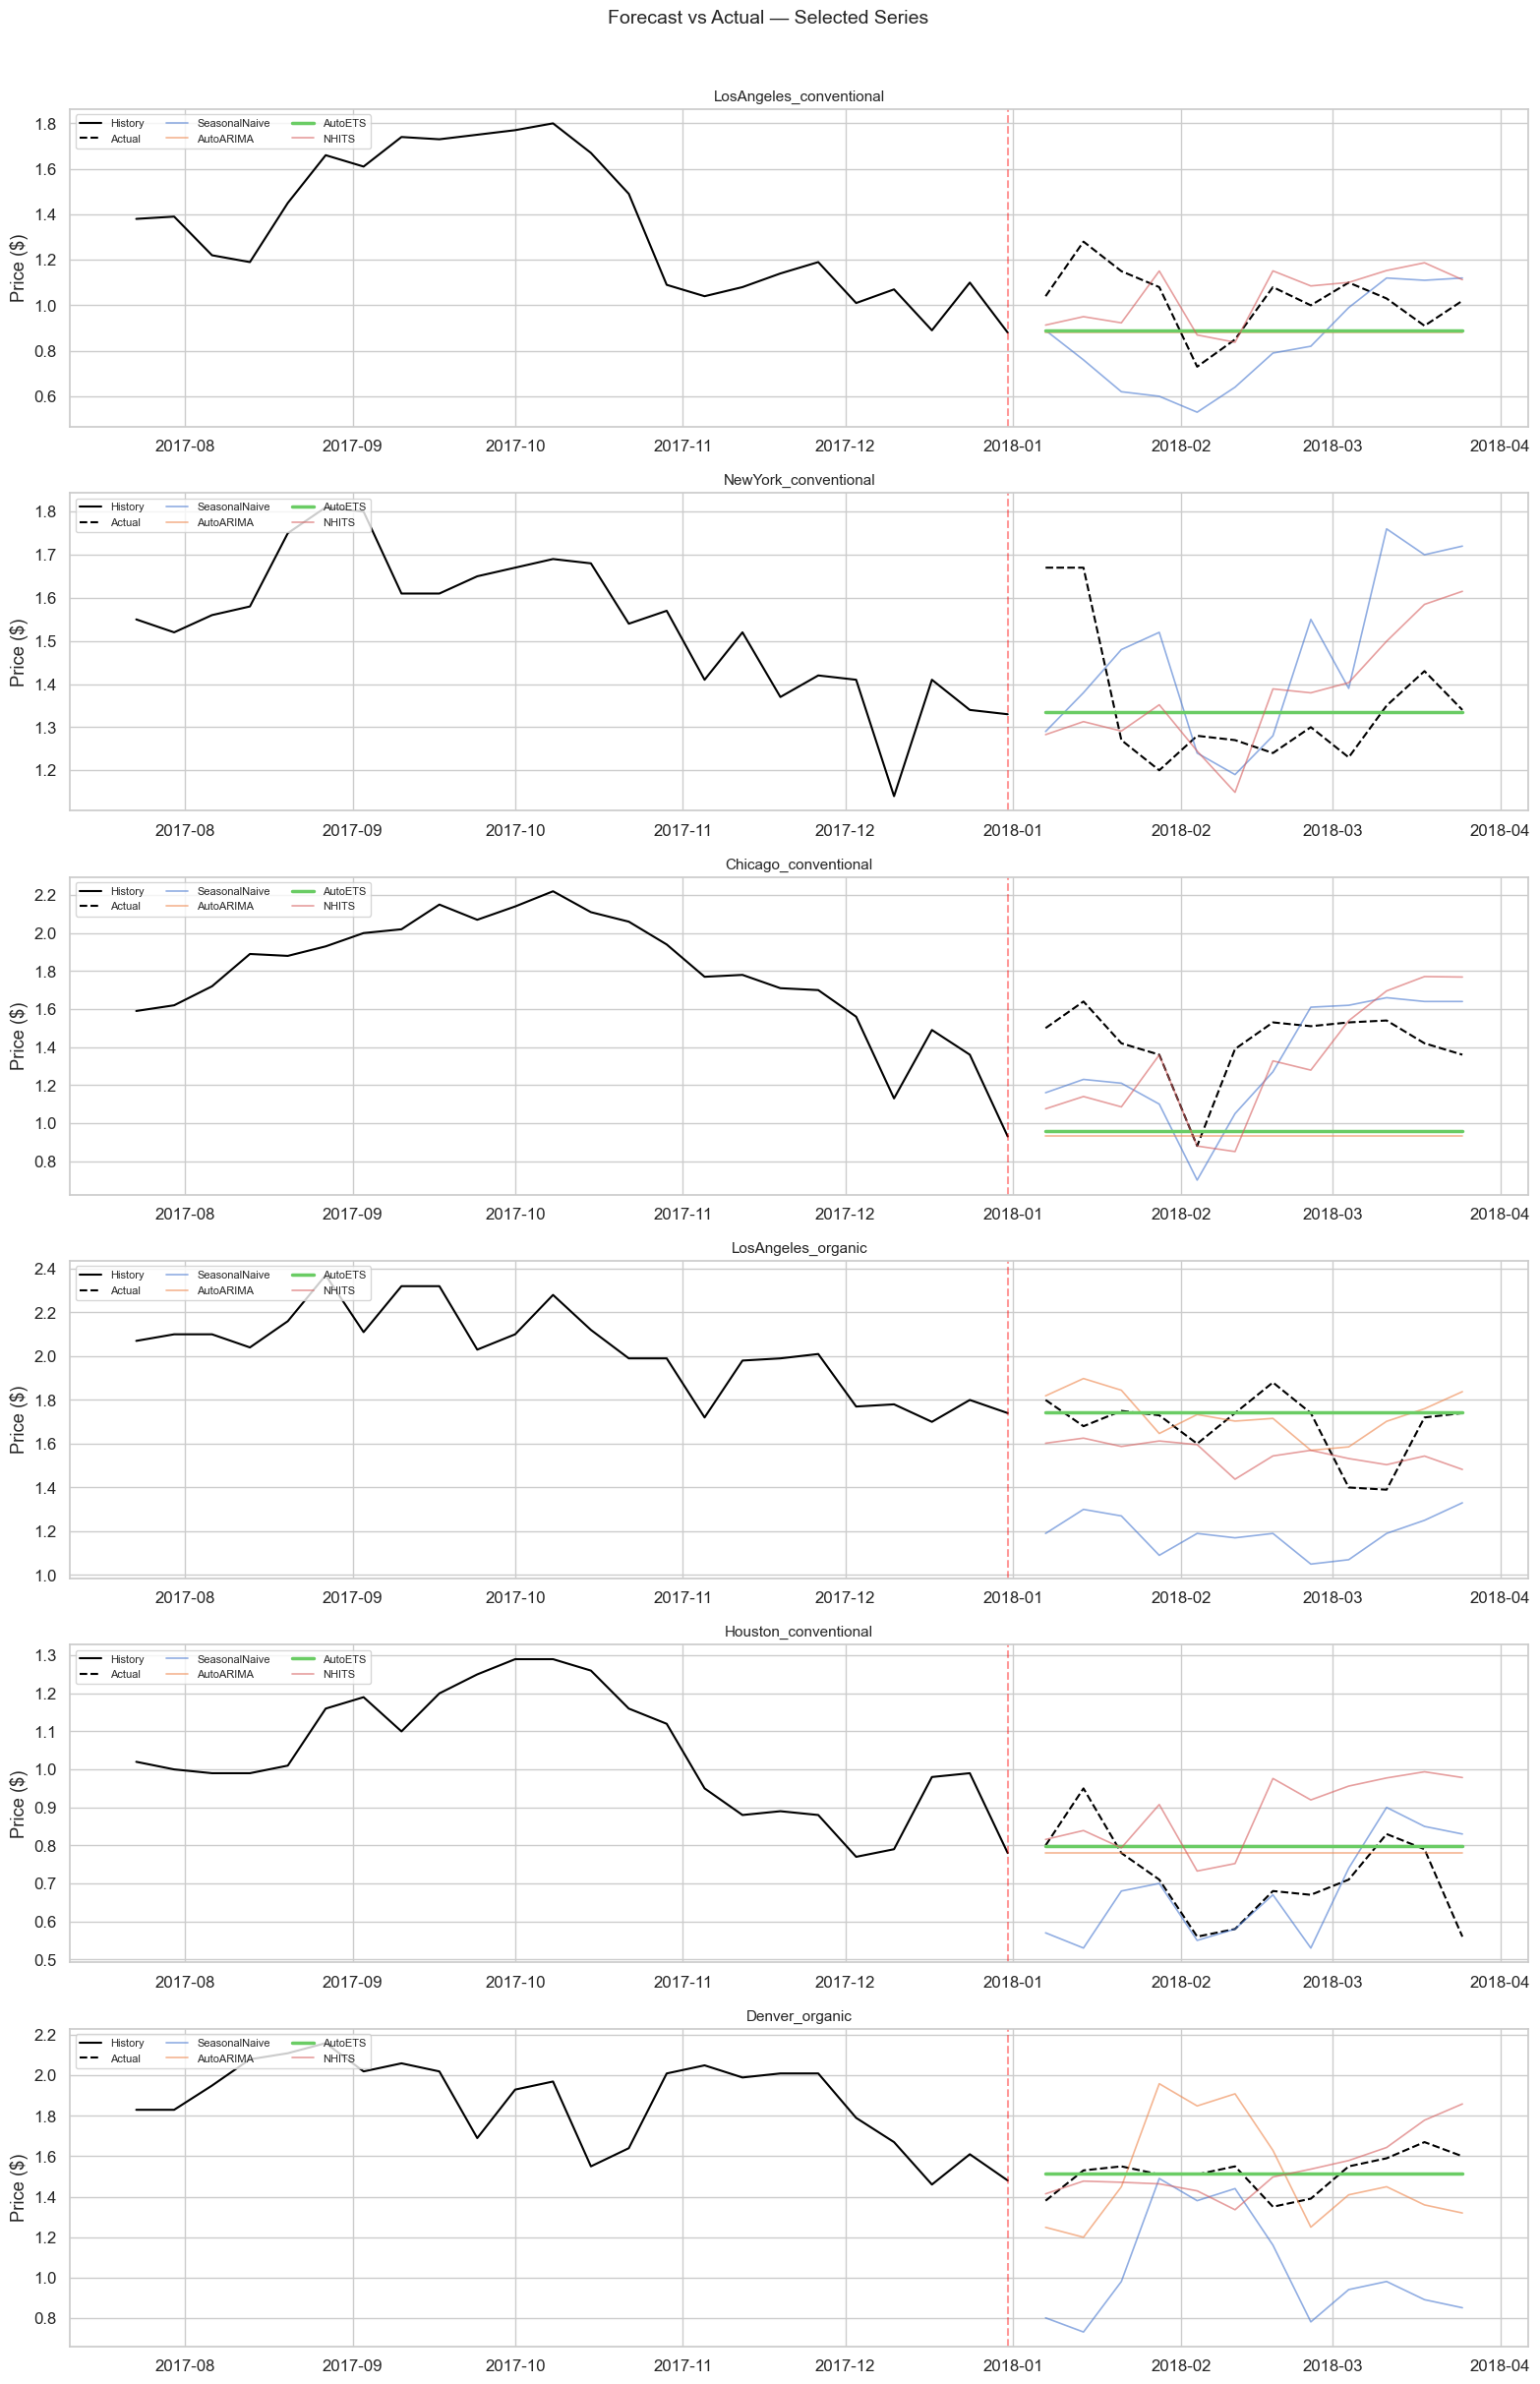

In [11]:
# Select diverse regions for visual inspection
PLOT_IDS = [
    "LosAngeles_conventional",
    "NewYork_conventional",
    "Chicago_conventional",
    "LosAngeles_organic",
    "Houston_conventional",
    "Denver_organic",
]
# Filter to series that actually exist in our data
PLOT_IDS = [uid for uid in PLOT_IDS if uid in all_cv["unique_id"].values]

n_plots = len(PLOT_IDS)
fig, axes = plt.subplots(n_plots, 1, figsize=(16, 4 * n_plots), sharex=False)
if n_plots == 1:
    axes = [axes]

best_model = metrics_df.index[0]  # model with lowest MAE

for ax, uid in zip(axes, PLOT_IDS):
    # Training history (last 24 weeks before cutoff)
    train_tail = nf_df[(nf_df["unique_id"] == uid) & (nf_df["ds"] <= cutoff_date)].tail(2 * H)
    # Test actuals + forecasts
    test = all_cv[all_cv["unique_id"] == uid].sort_values("ds")

    ax.plot(train_tail["ds"], train_tail["y"], color="black", linewidth=1.5, label="History")
    ax.plot(test["ds"], test["y"], color="black", linewidth=1.5, linestyle="--", label="Actual")

    for model in ALL_MODELS:
        lw = 2.5 if model == best_model else 1.2
        alpha = 1.0 if model == best_model else 0.6
        ax.plot(test["ds"], test[model], linewidth=lw, alpha=alpha, label=model)

    ax.axvline(cutoff_date, color="red", ls="--", alpha=0.4)
    ax.set_title(uid, fontsize=11)
    ax.set_ylabel("Price ($)")
    ax.legend(loc="upper left", fontsize=8, ncol=3)

plt.suptitle("Forecast vs Actual — Selected Series", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6.3 Per-Series Performance Distribution

How consistently does each model perform **across all 90+ series**?  
A model with low *median* MAE but huge *spread* is risky — it fails badly on some regions.

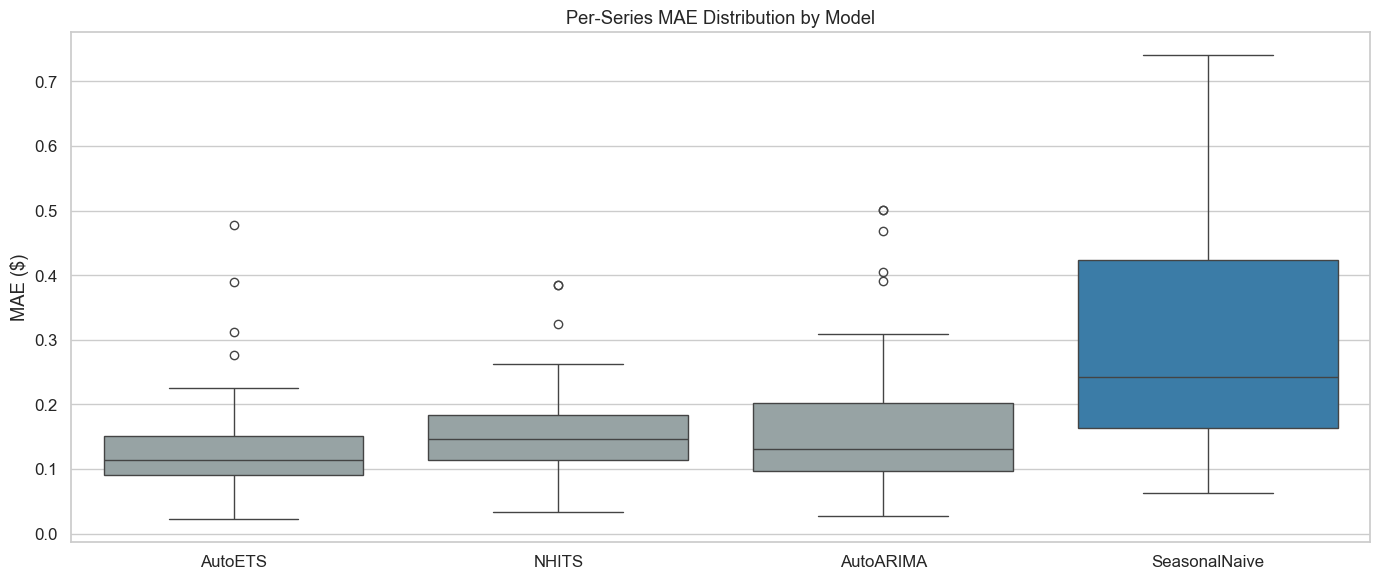

Median per-series MAE:


,Median MAE
Model,
AutoETS,0.114459
AutoARIMA,0.130166
NHITS,0.146809
SeasonalNaive,0.242083


In [12]:
# Compute MAE per (unique_id, model)
per_series = []
for model in ALL_MODELS:
    for uid, grp in all_cv.groupby("unique_id"):
        mae = np.abs(grp["y"] - grp[model]).mean()
        per_series.append({"unique_id": uid, "Model": model, "MAE": mae})

per_series_df = pd.DataFrame(per_series)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=per_series_df, x="Model", y="MAE",
    order=metrics_df.index,  # sorted by aggregate MAE
    palette=["#95a5a6"] * len(SF_MODELS) + ["#2980b9"] * len(NF_MODELS),
    ax=ax,
)
ax.set_title("Per-Series MAE Distribution by Model")
ax.set_ylabel("MAE ($)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

# Median MAE per model
print("Median per-series MAE:")
display(per_series_df.groupby("Model")["MAE"].median().sort_values().to_frame("Median MAE"))

### 6.4 Ensemble Models

Three ensemble strategies combining all five base models (SeasonalNaive, AutoARIMA, AutoETS, AutoTheta, NHITS):

| Ensemble | Logic | Caveat |
|---|---|---|
| **Mean** | Unweighted average — all models contribute equally | None |
| **Weighted (global)** | `w = 1/MAE`, normalised — better models get more say across all series | None |
| **Weighted (per-series)** | Same logic but weights computed per `unique_id` — each region uses the blend that worked best for it | Weights derived from the same test fold → optimistic upper bound, not for direct comparison |

The per-series variant tells us how much headroom there is if we could route each region to its optimal blend — useful as a north-star target.

In [ ]:
# ---- Build ensembles on the merged CV predictions ----

# 1. Simple mean ensemble
all_cv["Ensemble_mean"] = all_cv[ALL_MODELS].mean(axis=1)

# 2. Global weighted ensemble: weight each model by 1 / its aggregate CV MAE
model_mae = {m: np.abs(all_cv["y"] - all_cv[m]).mean() for m in ALL_MODELS}
inv_mae   = {m: 1.0 / v for m, v in model_mae.items()}
total_inv = sum(inv_mae.values())
weights   = {m: v / total_inv for m, v in inv_mae.items()}   # kept for future forecasts

print("Global ensemble weights (inverse-MAE):")
for m, w in sorted(weights.items(), key=lambda x: -x[1]):
    print(f"  {m:20s}: {w:.3f}  (MAE={model_mae[m]:.4f})")

all_cv["Ensemble_weighted"] = sum(all_cv[m] * w for m, w in weights.items())

# 3. Per-series weighted ensemble: each unique_id gets its own weight vector
#    NOTE: weights are derived from the same test fold → this is an optimistic
#    upper bound and should not be compared directly to globally-derived metrics.
per_series_mae_df = pd.DataFrame({
    m: all_cv.groupby("unique_id").apply(lambda g: np.abs(g["y"] - g[m]).mean())
    for m in ALL_MODELS
})  # shape: (n_series, n_models)

per_series_inv        = 1.0 / per_series_mae_df
per_series_weights    = per_series_inv.div(per_series_inv.sum(axis=1), axis=0)

def _weighted_by_series(group):
    uid = group["unique_id"].iloc[0]
    w   = per_series_weights.loc[uid]
    return sum(group[m] * w[m] for m in ALL_MODELS)

all_cv["Ensemble_per_series"] = (
    all_cv.groupby("unique_id", group_keys=False).apply(_weighted_by_series)
)

ENSEMBLE_MODELS = ["Ensemble_mean", "Ensemble_weighted", "Ensemble_per_series"]
EXTENDED_MODELS = ALL_MODELS + ENSEMBLE_MODELS
print(f"\nAll models tracked: {EXTENDED_MODELS}")

In [ ]:
# ---- Extended metrics table: base models + ensembles ----
ext_metrics_rows = []
for model in EXTENDED_MODELS:
    m = compute_metrics(all_cv["y"], all_cv[model])
    m["Model"] = model
    ext_metrics_rows.append(m)

ext_metrics_df = (
    pd.DataFrame(ext_metrics_rows)
    .set_index("Model")[["MAE", "RMSE", "MAPE", "SMAPE"]]
    .sort_values("MAE")
)

# Ensemble_per_series is an optimistic upper bound — mark it
ext_metrics_df_display = ext_metrics_df.copy()
ext_metrics_df_display.index = [
    f"{i} (*)" if i == "Ensemble_per_series" else i
    for i in ext_metrics_df_display.index
]

print("="*70)
print("EXTENDED METRICS — Base models + Ensembles")
print("(*) per-series weights derived from same fold → optimistic upper bound")
print("="*70)
display(
    ext_metrics_df_display.style
    .highlight_min(axis=0, color="#d4edda")
    .format("{:.4f}", subset=["MAE", "RMSE"])
    .format("{:.2f}%", subset=["MAPE", "SMAPE"])
)

# Primary model for downstream use = Ensemble_weighted (globally fair)
PRIMARY_MODEL = "Ensemble_weighted"
print(f"\n→ Primary model selected: {PRIMARY_MODEL}")

# ---- Bar chart: MAE comparison ----
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

color_map = (
    {m: "#95a5a6" for m in SF_MODELS} |
    {m: "#2980b9" for m in NF_MODELS} |
    {"Ensemble_mean":       "#52be80"} |
    {"Ensemble_weighted":   "#1e8449"} |   # primary — darkest green
    {"Ensemble_per_series": "#a9dfbf"} |   # upper bound — light green
)
ordered_colors_mae  = [color_map[m] for m in ext_metrics_df.index]
ordered_colors_mape = ordered_colors_mae

ext_metrics_df["MAE"].plot.barh(ax=axes[0], color=ordered_colors_mae, edgecolor="white")
axes[0].set_title("MAE — Base Models vs Ensembles")
axes[0].set_xlabel("Mean Absolute Error ($)")
axes[0].invert_yaxis()

ext_metrics_df["MAPE"].plot.barh(ax=axes[1], color=ordered_colors_mape, edgecolor="white")
axes[1].set_title("MAPE % — Base Models vs Ensembles")
axes[1].set_xlabel("Mean Absolute Percentage Error")
axes[1].invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(color="#95a5a6", label="Statistical"),
    Patch(color="#2980b9", label="Neural"),
    Patch(color="#52be80", label="Ensemble mean"),
    Patch(color="#1e8449", label="Ensemble weighted (primary)"),
    Patch(color="#a9dfbf", label="Ensemble per-series (upper bound)"),
]
axes[0].legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.suptitle("Model Comparison — All Models + Ensembles", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ---- Per-series MAE distribution — all 6 models ----
per_series_ext = []
for model in EXTENDED_MODELS:
    for uid, grp in all_cv.groupby("unique_id"):
        mae = np.abs(grp["y"] - grp[model]).mean()
        per_series_ext.append({"unique_id": uid, "Model": model, "MAE": mae})

per_series_ext_df = pd.DataFrame(per_series_ext)

fig, ax = plt.subplots(figsize=(16, 6))
palette = (
    {m: "#95a5a6" for m in SF_MODELS} |
    {m: "#2980b9" for m in NF_MODELS} |
    {m: "#27ae60" for m in ENSEMBLE_MODELS}
)
sns.boxplot(
    data=per_series_ext_df,
    x="Model", y="MAE",
    order=ext_metrics_df.index,
    palette=palette,
    ax=ax,
)
ax.set_title("Per-Series MAE Distribution — Base Models vs Ensembles")
ax.set_ylabel("MAE ($)")
ax.set_xlabel("")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

print("\nMedian per-series MAE (all models):")
display(
    per_series_ext_df.groupby("Model")["MAE"]
    .median()
    .sort_values()
    .rename("Median MAE")
    .to_frame()
)

In [ ]:
# ---- Visual: ensemble vs base models on selected series ----
PLOT_IDS_ENS = [uid for uid in PLOT_IDS if uid in all_cv["unique_id"].values]

fig, axes = plt.subplots(len(PLOT_IDS_ENS), 1, figsize=(16, 4 * len(PLOT_IDS_ENS)), sharex=False)
if len(PLOT_IDS_ENS) == 1:
    axes = [axes]

for ax, uid in zip(axes, PLOT_IDS_ENS):
    train_tail = nf_df[(nf_df["unique_id"] == uid) & (nf_df["ds"] <= cutoff_date)].tail(2 * H)
    test = all_cv[all_cv["unique_id"] == uid].sort_values("ds")

    ax.plot(train_tail["ds"], train_tail["y"], color="black", linewidth=1.5, label="History")
    ax.plot(test["ds"], test["y"], color="black", linewidth=1.5, linestyle="--", label="Actual")

    # Base models — thin, muted
    for model in ALL_MODELS:
        ax.plot(test["ds"], test[model], linewidth=1, alpha=0.45, linestyle="--", label=model)

    # Ensembles — thick, green
    ax.plot(test["ds"], test["Ensemble_mean"],     linewidth=2.5, color="#27ae60", label="Ensemble mean")
    ax.plot(test["ds"], test["Ensemble_weighted"],  linewidth=2.5, color="#1a6e3e", linestyle=":", label="Ensemble weighted")

    ax.axvline(cutoff_date, color="red", ls="--", alpha=0.4)
    ax.set_title(uid, fontsize=11)
    ax.set_ylabel("Price ($)")
    ax.legend(loc="upper left", fontsize=8, ncol=3)

plt.suptitle("Forecast vs Actual — Ensemble vs Base Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Residual Diagnostics

Good residuals should be:
1. **Centred around zero** (no systematic bias).
2. **Approximately normal** (or at least symmetric).
3. **No autocorrelation** (the model captured all temporal patterns).

We examine residuals for the **best model** identified above.

In [ ]:
# Residuals for the PRIMARY (ensemble weighted) model
residuals = all_cv["y"] - all_cv[PRIMARY_MODEL]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 7.1 — Residual distribution
axes[0].hist(residuals, bins=50, edgecolor="white", density=True, alpha=0.8)
axes[0].axvline(0, color="red", ls="--", lw=1.5)
axes[0].set_title(f"Residual Distribution — {PRIMARY_MODEL}")
axes[0].set_xlabel("Residual ($)")
axes[0].set_ylabel("Density")

axes[0].annotate(
    f"mean={residuals.mean():.4f}\nstd={residuals.std():.4f}\nskew={residuals.skew():.2f}",
    xy=(0.98, 0.95), xycoords="axes fraction", ha="right", va="top",
    fontsize=9, bbox=dict(boxstyle="round", fc="wheat", alpha=0.8),
)

# 7.2 — Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title(f"Q-Q Plot — {PRIMARY_MODEL}")
axes[1].get_lines()[1].set_color("red")

# 7.3 — Residuals over time
axes[2].scatter(all_cv["ds"], residuals, alpha=0.3, s=8, c="steelblue")
axes[2].axhline(0, color="red", ls="--", lw=1.5)
axes[2].set_title(f"Residuals Over Time — {PRIMARY_MODEL}")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Residual ($)")

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import acf

max_lag = min(H - 1, 10)
acf_list = []
for uid, grp in all_cv.groupby("unique_id"):
    resid = (grp["y"] - grp[PRIMARY_MODEL]).values
    if len(resid) > max_lag + 1:
        acf_vals = acf(resid, nlags=max_lag, fft=False)
        acf_list.append(acf_vals)

avg_acf = np.mean(acf_list, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(avg_acf)), avg_acf, color="steelblue", edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.axhline( 1.96 / np.sqrt(H), color="red", ls="--", alpha=0.5, label="95% CI")
ax.axhline(-1.96 / np.sqrt(H), color="red", ls="--", alpha=0.5)
ax.set_title(f"Average Residual ACF — {PRIMARY_MODEL}")
ax.set_xlabel("Lag (weeks)")
ax.set_ylabel("Autocorrelation")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Refit All Base Models & Export Ensemble Forecasts

The primary model is **`Ensemble_weighted`** — an inverse-MAE weighted combination of all five base models.

To generate future forecasts we:
1. **Refit all base models** on the full dataset (train + test).
2. **Combine their predictions** using the CV-derived global weights to produce the ensemble forecast.
3. **Export** CV results, future ensemble forecasts, and weights for downstream notebooks.

In [ ]:
# Refit NeuralForecast on full data
print(f"Refitting NeuralForecast on full dataset ({len(nf_df):,} rows)...")
t0 = time.time()
nf.fit(
    df=nf_df.drop(columns=STAT_EXOG),
    static_df=static_df,
    val_size=H,
)
print(f"✔ NeuralForecast refit done in {time.time()-t0:.1f}s")

In [16]:
# Generate future exogenous features for the next H weeks
last_dates = nf_df.groupby("unique_id")["ds"].max()
all_ids = nf_df["unique_id"].unique()

futr_rows = []
for uid in all_ids:
    last_date = last_dates[uid]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1), periods=H, freq="W")
    for d in future_dates:
        row = {"unique_id": uid, "ds": d}
        # Calendar features — computable for any future date
        row["month_sin"] = np.sin(2 * np.pi * d.month / 12)
        row["month_cos"] = np.cos(2 * np.pi * d.month / 12)
        iso_week = d.isocalendar()[1]
        row["week_sin"]  = np.sin(2 * np.pi * iso_week / 52)
        row["week_cos"]  = np.cos(2 * np.pi * iso_week / 52)
        row["is_holiday_week"] = 0  # could be computed with holidays package
        futr_rows.append(row)

futr_df = pd.DataFrame(futr_rows)
print(f"Future exogenous DataFrame: {futr_df.shape}")
futr_df.head()

Future exogenous DataFrame: (1032, 7)


,unique_id,ds,month_sin,month_cos,week_sin,week_cos,is_holiday_week
0,Albany_conventional,2018-04-01,0.866025,-0.5,1.000000,-1.608123e-16,0
1,Albany_conventional,2018-04-08,0.866025,-0.5,0.992709,-1.205367e-01,0
2,Albany_conventional,2018-04-15,0.866025,-0.5,0.970942,-2.393157e-01,0
3,Albany_conventional,2018-04-22,0.866025,-0.5,0.935016,-3.546049e-01,0
4,Albany_conventional,2018-04-29,0.866025,-0.5,0.885456,-4.647232e-01,0


In [17]:
# Predict
forecasts = nf.predict(futr_df=futr_df)
forecasts = forecasts.reset_index()

print(f"Future forecasts: {forecasts.shape}")
forecasts.head()

Predicting: |          | 0/? [00:00<?, ?it/s]

Future forecasts: (1032, 4)


,index,unique_id,ds,NHITS
0,0,Albany_conventional,2018-04-01,1.411687
1,1,Albany_conventional,2018-04-08,1.574718
2,2,Albany_conventional,2018-04-15,1.498870
3,3,Albany_conventional,2018-04-22,1.488256
4,4,Albany_conventional,2018-04-29,1.473515


In [ ]:
# ---- Generate all statistical model future forecasts on full dataset ----
print("Generating StatsForecast future forecasts on full dataset...")
t0 = time.time()
sf_future = sf.forecast(h=H, df=sf_df)
sf_future = sf_future.reset_index()
print(f"✔ StatsForecast future done in {time.time()-t0:.1f}s  shape={sf_future.shape}")

# Merge neural + statistical future forecasts
forecasts = forecasts.merge(
    sf_future[["unique_id", "ds"] + SF_MODELS],
    on=["unique_id", "ds"],
    how="left",
)
print(f"Merged future forecasts columns: {list(forecasts.columns)}")
forecasts.head(3)

In [ ]:
# ---- Compute ensemble future forecasts using CV-derived global weights ----
available_base = [m for m in ALL_MODELS if m in forecasts.columns]
print(f"Base models in future forecasts: {available_base}")

# Renormalise weights in case not all models are present
avail_inv   = {m: inv_mae[m] for m in available_base}
avail_total = sum(avail_inv.values())
avail_weights = {m: v / avail_total for m, v in avail_inv.items()}

forecasts["Ensemble_mean"]     = forecasts[available_base].mean(axis=1)
forecasts["Ensemble_weighted"] = sum(forecasts[m] * avail_weights[m] for m in available_base)

# Per-series weighted ensemble (uses same per_series_weights from CV)
def _future_per_series(group):
    uid = group["unique_id"].iloc[0]
    if uid not in per_series_weights.index:
        return sum(group[m] * avail_weights[m] for m in available_base)
    w = per_series_weights.loc[uid]
    return sum(group[m] * w[m] for m in available_base)

forecasts["Ensemble_per_series"] = (
    forecasts.groupby("unique_id", group_keys=False).apply(_future_per_series)
)

print(f"Ensemble future forecast columns added: Ensemble_mean, Ensemble_weighted, Ensemble_per_series")
forecasts[["unique_id", "ds", "Ensemble_weighted"] + available_base].head(3)

In [ ]:
# Plot future forecasts — ensemble (primary) + all base models for reference
DEMO_IDS = ["LosAngeles_conventional", "NewYork_conventional", "Denver_organic"]
DEMO_IDS = [uid for uid in DEMO_IDS if uid in forecasts["unique_id"].values]

fig, axes = plt.subplots(len(DEMO_IDS), 1, figsize=(14, 4 * len(DEMO_IDS)))
if len(DEMO_IDS) == 1:
    axes = [axes]

available_base = [m for m in ALL_MODELS if m in forecasts.columns]

for ax, uid in zip(axes, DEMO_IDS):
    hist = nf_df[nf_df["unique_id"] == uid].tail(3 * H)
    fut  = forecasts[forecasts["unique_id"] == uid]

    ax.plot(hist["ds"], hist["y"], color="black", linewidth=1.5, label="History")

    # Base models — thin and muted
    for model in available_base:
        ax.plot(fut["ds"], fut[model], linewidth=1, alpha=0.4, linestyle="--", label=model)

    # Primary: Ensemble_weighted — thick green
    ax.plot(fut["ds"], fut["Ensemble_weighted"], linewidth=2.5, color="#1e8449",
            marker="o", markersize=4, label="Ensemble_weighted (primary)")

    ax.axvline(hist["ds"].max(), color="grey", ls=":", alpha=0.6)
    ax.set_title(f"Future Forecast — {uid}")
    ax.set_ylabel("Price ($)")
    ax.legend(fontsize=8, ncol=3)

plt.suptitle("Future Forecasts — Ensemble_weighted vs Base Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ---- Export artefacts ----

# 1. Cross-validation results (all base models + ensembles)
cv_path = DATA_OUTPUTS / "forecast_cv_results.csv"
all_cv.to_csv(cv_path, index=False)
print(f"✔ CV results saved            : {cv_path}")

# 2. Future forecasts — base models + Ensemble_weighted (primary) + variants
fc_path = DATA_OUTPUTS / "forecast_future.csv"
forecasts.to_csv(fc_path, index=False)
future_model_cols = [c for c in forecasts.columns if c not in ["index", "unique_id", "ds"]]
print(f"✔ Future forecasts saved       : {fc_path}  columns={future_model_cols}")

# 3. Primary forecast (Ensemble_weighted) as a clean standalone file for nb04
primary_fc_path = DATA_OUTPUTS / "forecast_primary.csv"
(
    forecasts[["unique_id", "ds", "Ensemble_weighted"]]
    .rename(columns={"Ensemble_weighted": "forecast"})
    .to_csv(primary_fc_path, index=False)
)
print(f"✔ Primary forecast saved       : {primary_fc_path}  (model={PRIMARY_MODEL})")

# 4. Metrics summary
met_path = DATA_OUTPUTS / "forecast_metrics.csv"
ext_metrics_df.to_csv(met_path)
print(f"✔ Metrics saved                : {met_path}")

# 5. Ensemble weights (for reproducibility and API use)
weights_df = pd.DataFrame([
    {"model": m, "global_weight": weights[m], "cv_mae": model_mae[m]}
    for m in ALL_MODELS
]).sort_values("global_weight", ascending=False)
weights_df.to_csv(DATA_OUTPUTS / "ensemble_weights.csv", index=False)
print(f"✔ Ensemble weights saved       : {DATA_OUTPUTS / 'ensemble_weights.csv'}")

# 6. NeuralForecast model
model_dir = DATA_OUTPUTS / "nf_model"
nf.save(path=str(model_dir), overwrite=True)
print(f"✔ NeuralForecast model saved   : {model_dir}")

# 7. Per-series MAE
ps_path = DATA_OUTPUTS / "forecast_per_series_mae.csv"
per_series_ext_df.to_csv(ps_path, index=False)
print(f"✔ Per-series MAE saved         : {ps_path}")

print(f"\n→ Primary model for downstream use: {PRIMARY_MODEL}")

## Summary

### Models trained

| Model | Type | Role |
|---|---|---|
| Seasonal Naïve | Statistical baseline | Base model |
| AutoARIMA | Statistical | Base model |
| AutoETS | Statistical | Base model |
| AutoTheta | Statistical (M3 winner) | Base model |
| NHITS | Deep learning (NeuralForecast) | Base model |
| **Ensemble_weighted** | Inverse-MAE weighted blend | **Primary model ⭐** |

### Key takeaways

- `Ensemble_weighted` combines all 5 base models using weights proportional to `1/MAE` — models that performed better individually contribute more.
- The per-series distribution (section 6.4) shows the ensemble is not only better on average but also more **consistent** across regions.
- Residual diagnostics (section 7) target `Ensemble_weighted` as the primary model.

### Artefacts exported

| File | Content |
|---|---|
| `data/outputs/forecast_primary.csv` | Clean `unique_id / ds / forecast` for downstream notebooks (Ensemble_weighted) |
| `data/outputs/forecast_cv_results.csv` | Cross-validation predictions from all models + ensembles |
| `data/outputs/forecast_future.csv` | 12-week future forecasts for all models + ensembles |
| `data/outputs/forecast_metrics.csv` | Aggregate metrics summary |
| `data/outputs/ensemble_weights.csv` | Global weights per base model (for API reproducibility) |
| `data/outputs/forecast_per_series_mae.csv` | Per-series MAE for all models |
| `data/outputs/nf_model/` | Saved NeuralForecast model (NHITS) |

### Next → 04_pricing.ipynb

Uses `forecast_primary.csv` (`Ensemble_weighted`) + engineered features to build a pricing optimisation model.